# Predicting density change in Lima, Peru

## Preparation

- [Github link](https://github.com/Tbtaaa/DSSS_Assessment_TP) 

- Number of words: ***

- Runtime: ~10 minutes (Memory 10 GB, CPU Intel i7-10700 @2.90GHz)

- Coding environment: Jupyter Notebook (Python 3.12, Conda environment)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library
    - **shap** (model interpretation)
    - **scikit-learn** (machine learning)

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Urban population growth in Latin American cities is shaped by a complex interaction of physical, socio-economic, and infrastructural factors. Lima, Peru, offers a particularly relevant context to examine these dynamics. As a large metropolitan area characterised by socio-spatial fragmentation, Lima has experienced significant changes in both population distribution and urban form. 

From an urban planning perspective, density growth is often linked to accessibility and transport infrastructure, as suggested by Transit-Oriented Development theory (Cervero & Kockelman, 1997). However, in contexts like Lima, the relationship between transport accessibility and urban development is not always straightforward (Vega Centeno, 2014). Additionally, spatial interaction and accessibility theories suggest that urban patterns emerge from the interaction between locations, shaped by both the attractiveness of destinations and the friction of distance (Hansen, 1959; Wilson, 1971).

This study investigates whether urban and accessibility-related features can predict changes in population density in Lima between 2007 and 2017, period in which the city underwent an uneven density change, alongside the introduction of major transport infrastructure.

Using a supervised machine learning approach, the analysis considers multiple explanatory variables, including accessibility to transport systems, terrain conditions, and socio-economic characteristics, at the hexagon level. Rather than assuming a dominant role for any single factor, this approach evaluates the relative contribution of different variables to density change.

## Research questions

[[ go back to the top ]](#Table-of-contents)

This study addresses the following research questions:

**Can urban and accessibility features explain density change in Lima between 2007 and 2017?** Specifically, which variables contribute most to explaining density change, and to what extent does model performance suggest that important drivers may be missing from the dataset?

## Data

[[ go back to the top ]](#Table-of-contents)

The dataset used in this study was pre-processed and included a set of variables capturing demographic, socio-economic, transport, and physical characteristics at the hexagon level. These variables comprised population density in 2007 (dn_2007) and 2017 (dn_2017), as well as absolute density change (dns_dff). In addition, the dataset included socio-economic status (SES), median slope (slop_md), the number of conventional public transport routes (CPT_rt), proximity to metropolitan transport infrastructure (MT_prox), and the presence of metropolitan attractors (attrac).

For the purpose of the analysis, population density change is measured using the logarithmic transformation of the ratio between 2017 and 2007 densities (log(dn_2017 / dn_2007)). This approach captures proportional rather than absolute changes, making it more suitable for comparing areas with different initial density levels. The original density variables were subsequently removed to avoid redundancy.

Together, these variables allow the model to capture both accessibility and attractiveness effects, as well as spatial constraints, which are central to understanding density change. However, the dataset does not include other potential drivers of density change, such as land-use regulation or housing market dynamics, which may influence model performance.

The final set of variables used in this study is summarised below.

| Variable   | Type        | Role      | Description                                                            |
| ---------- | ----------- | --------- | ---------------------------------------------------------------------- |
| MT_prox    | Binary      | Predictor | Indicator for proximity to metropolitan transport infrastructure, meaning hexagons that are inside a 500-metre radius from a BRT or Metro Line station (influence area of metropolitan transport infrastructure defined by the Ministry of Housing, Construction and Sanitation.)      |
| CPT_rt     | Numeric     | Predictor | Number of conventional public transport routes per hexagon                        |
| dns_dfflog | Numeric     | Target    | Logarithmic change in population density between 2007 and 2017         |
| attrac     | Binary      | Predictor | Indicator: 1 if the hexagon intersects an area previously identified as a metropolitan attractor    |
| slop_md    | Numeric     | Predictor | Median slope value per hexagon                                                     |
| SES        | Numeric     | Predictor | Mean socio-economic status per hexagon                                             |

## Methodology

[[ go back to the top ]](#Table-of-contents)

The analysis is conducted at the hexagon level, where each spatial unit contains a set of explanatory variables (X) and a target variable (Y), defined as the logarithmic change in population density. A Random Forest model is used due to its ability to capture complex and non-linear relationships between variables, which are common in urban system. 

![Flowchart](https://raw.githubusercontent.com/Tbtaaa/DSSS_Assessment_TP/main/graph_01.jpg)

**Data preparation**

In [1]:
#!pip install shap

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import dataset
hex = gpd.read_file("data/hexagon_grid/hex_clean_.shp")
hex.columns

Index(['hex_id', 'dn_2007', 'dn_2017', 'dns_dff', 'SES', 'slop_md', 'CPT_rt',
       'MT_prox', 'MT_group', 'attrac', 'geometry'],
      dtype='object')

In [4]:
# Create log density change  
hex["dns_dfflog"] = np.where(
    (hex["dn_2007"] > 0) & (hex["dn_2017"] > 0),
    np.log(hex["dn_2017"] / hex["dn_2007"]),
    np.nan)

# Clean dataset with columns to use and examinate
vars_keep = ["SES", "slop_md", "CPT_rt", "MT_prox", "attrac","dns_dfflog"]
hex_df = hex[vars_keep].copy()
hex_df.describe

<bound method NDFrame.describe of        SES  slop_md  CPT_rt  MT_prox  attrac  dns_dfflog
0      4.0     5.71     0.0      0.0       0   -0.298431
1      4.0     5.11     0.0      0.0       0   -1.058161
2      2.0    11.31     0.0      0.0       0   -0.611660
3      3.0     6.89     0.0      0.0       0   -1.247110
4      3.0    11.64     0.0      0.0       0   -1.595559
...    ...      ...     ...      ...     ...         ...
15323  3.0     5.42     6.0      0.0       0   -0.258784
15324  2.0    37.09     0.0      0.0       0   -0.247677
15325  3.0     6.45     5.0      0.0       0   -2.964682
15326  3.0     6.89     0.0      0.0       0    0.056873
15327  2.0    40.00     0.0      0.0       0    0.920860

[15328 rows x 6 columns]>

**Dependent variable check**

The dependent variable is defined as the logarithmic change in population density between 2007 and 2017 (dns_dfflog). As shown, the distribution of the variable is approximately centred around zero, indicating a balance between areas experiencing density growth and decline. The distribution appears relatively symmetric, although slightly right-skewed, suggesting the presence of some areas with higher positive density change. The use of the logarithmic transformation helps reduce skewness and limits the influence of extreme values, resulting in a more stable dependent variable for modelling. A small number of observations (44 hexagons) contained missing values, representing less than 0.3% of the dataset. Given their negligible proportion, these observations were removed without significantly affecting the overall distribution. The final sample consists of 15,284 observations.

The variable is well-behaved for modelling purposes, with a mean close to zero (0.12) and a moderate standard deviation (0.88), indicating variation in density change across the study area.

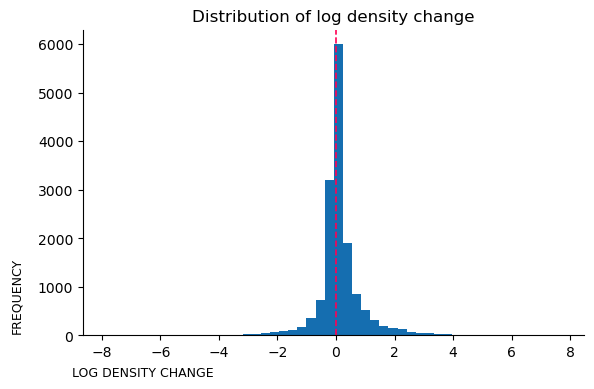

In [5]:
# Check the distribution of the dependent variable
fig, ax = plt.subplots(figsize=(6, 4))

hex_df["dns_dfflog"].hist(bins=50,ax=ax,color="#156eb0",)

ax.set_title("Distribution of log density change", fontsize=12)
ax.set_xlabel("LOG DENSITY CHANGE", fontsize=9)
ax.set_ylabel("FREQUENCY", fontsize=9)

ax.xaxis.set_label_coords(0.12, -0.1)
ax.yaxis.set_label_coords(-0.12, 0.13)

# remove right and top lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# left and bottom lines
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(False)
ax.axvline(x=0, color='#ff0054', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.show()

In [6]:
# Check for missing values
hex_df.isna().sum()

SES            0
slop_md        0
CPT_rt         0
MT_prox        0
attrac         0
dns_dfflog    44
dtype: int64

In [7]:
# Just 44 with missing values, drop them
hex_df = hex_df.dropna()

In [8]:
# Check final version of dependent variable
hex_df["dns_dfflog"].describe()

count    15284.000000
mean         0.124894
std          0.881460
min         -7.861342
25%         -0.135974
50%          0.033618
75%          0.298480
max          7.705938
Name: dns_dfflog, dtype: float64

**Independent variables check**

The variable CPT_rt (number of conventional transport routes) shows a highly right-skewed distribution, with most hexagons having low values and a small number of areas concentrating higher values. This reflects the uneven spatial distribution of conventional public transport across the city. Similarly, the slope variable (slop_md) is positively skewed, indicating that most areas present relatively low slope values, while steeper terrains are less common. In contrast, the socio-economic variable (SES) displays a more discrete and balanced distribution across categories.

Binary variables show a clear imbalance. The proximity to mass transit (MT_prox) variable indicates that only a small proportion of hexagons are located near major transport infrastructure (1,327 out of 15,284). This imbalance is even more pronounced for the attractiveness variable (attrac), where only 205 hexagons are classified as metropolitan attractors. These distributions highlight the spatial concentration of key urban functions.

The correlation matrix indicates no strong multicollinearity among predictors, with all pairwise correlations remaining relatively low. This suggests that the selected variables capture different dimensions of the urban environment and can be jointly included in the model without redundancy issues.

In [9]:
# Check all independent variables
for col in hex_df.columns:
    print(col, hex_df[col].nunique())

SES 5
slop_md 1081
CPT_rt 86
MT_prox 2
attrac 2
dns_dfflog 15086


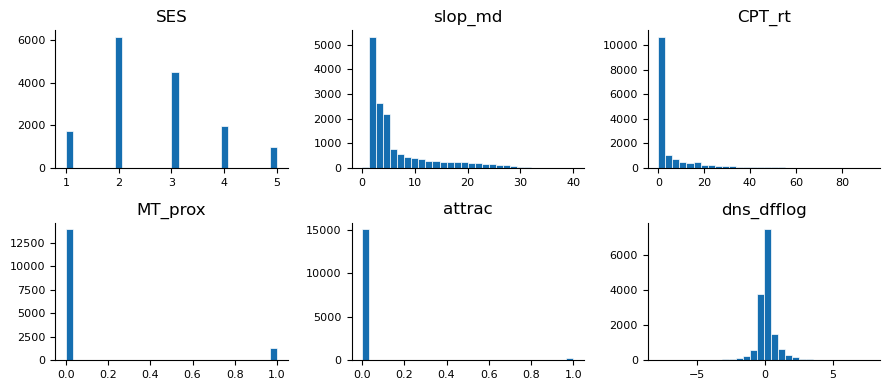

In [10]:
# Check distributions of all the variables
fig, axes = plt.subplots(2, 3, figsize=(9, 4))

# create histograms
hex_df.hist(ax=axes.flatten(), bins=30, color="#156eb0", edgecolor="white", linewidth=0.5)

# apply style to all plots
for ax in axes.flatten():
    
    # delete grid
    ax.grid(False)
    
    # remove right and top lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # left and bottom lines
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(labelsize=8)

# ajustar layout
plt.tight_layout()
plt.show()

In [11]:
# Examinate binary variables
print(hex_df["MT_prox"].value_counts(dropna=False))
print(hex_df["attrac"].value_counts(dropna=False))

MT_prox
0.0    13957
1.0     1327
Name: count, dtype: int64
attrac
0    15079
1      205
Name: count, dtype: int64


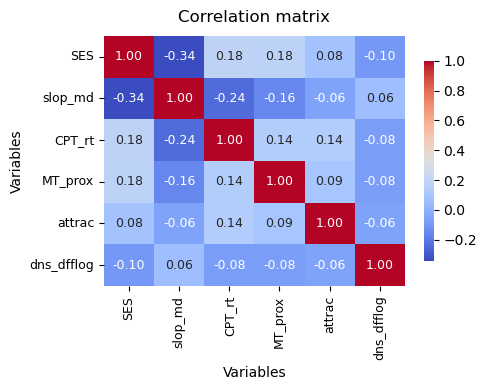

In [12]:
# Check correlation of independent variables 
corr = hex_df.corr(numeric_only=True)
plt.figure(figsize=(5, 4))

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",               
    annot_kws={"size": 9},    
    cbar_kws={"shrink": 0.8}   
)

# title
ax.set_title("Correlation matrix", fontsize=12, pad=10)

# labels
ax.set_xlabel("Variables", fontsize=10)
ax.set_ylabel("Variables", fontsize=10)

# ticks size
ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Check final dataset
hex_df.shape

(15284, 6)

**Data splitting and training**

The dataset is split into training (80%) and testing (20%) subsets to evaluate model performance on unseen data and reduce the risk of overfitting. The model is trained on the training subset using the selected explanatory variables, with density change as the target variable. A Random Forest regressor with 100 decision trees is used, and a fixed random state is applied to ensure reproducibility.

Model performance is evaluated using R² and Root Mean Squared Error (RMSE). R² measures the proportion of variance in the dependent variable explained by the model, while RMSE captures the average prediction error in the same units as the target variable.

In [14]:
# split train/test
X = hex_df.drop(columns=["dns_dfflog"])
y = hex_df["dns_dfflog"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [15]:
# Random forest regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# Evaluation
y_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2: -0.18985420540937614
RMSE: 0.9561004788023221


**Model interpretation**

To interpret the model outputs, multiple techniques are employed. Feature importance based on impurity reduction is used to provide an initial assessment of the relative contribution of each predictor within the Random Forest model.

In addition, permutation feature importance is applied as a model-agnostic method, evaluating the decrease in model performance when each variable is randomly permuted. This allows for a more robust assessment of variable relevance.

Finally, SHAP (SHapley Additive exPlanations) values are used to interpret the model at both global and local levels. Global SHAP values provide insight into overall feature influence across the dataset, while local explanations illustrate how individual variables contribute to specific predictions. Selected representative observations are used to demonstrate variability in model behaviour.

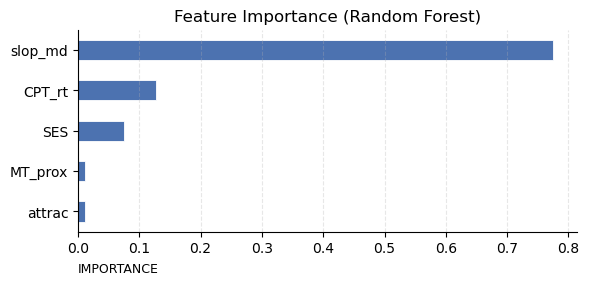

slop_md    0.774600
CPT_rt     0.127309
SES        0.075230
MT_prox    0.011901
attrac     0.010960
dtype: float64


In [17]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)  # horizontal

fig, ax = plt.subplots(figsize=(6, 3))

feat_imp.plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6)

# title
ax.set_title("Feature Importance (Random Forest)", fontsize=12)
ax.set_xlabel("IMPORTANCE", fontsize=9)
ax.set_ylabel("")

ax.xaxis.set_label_coords(0.08, -0.15)

# # remove right and top lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# smooth grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(feat_imp.sort_values(ascending=False))

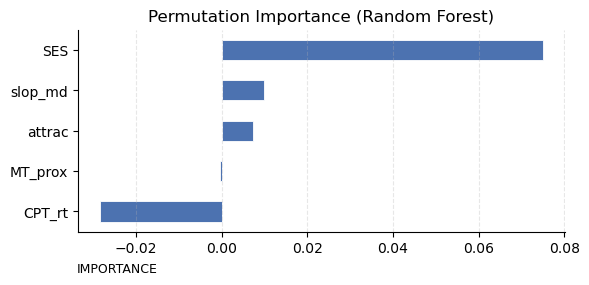

SES        0.074908
slop_md    0.009970
attrac     0.007222
MT_prox   -0.000301
CPT_rt    -0.028338
dtype: float64


In [18]:
# Permutation importance
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42)

perm_imp = pd.Series(perm.importances_mean, index=X.columns)
perm_imp = perm_imp.sort_values(ascending=True)  # horizontal

fig, ax = plt.subplots(figsize=(6, 3))

perm_imp.plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6)

# titles
ax.set_title("Permutation Importance (Random Forest)", fontsize=12)
ax.set_xlabel("IMPORTANCE", fontsize=9)
ax.set_ylabel("")

ax.xaxis.set_label_coords(0.08, -0.15)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(perm_imp.sort_values(ascending=False))

100%|===================| 3051/3057 [01:37<00:00]        

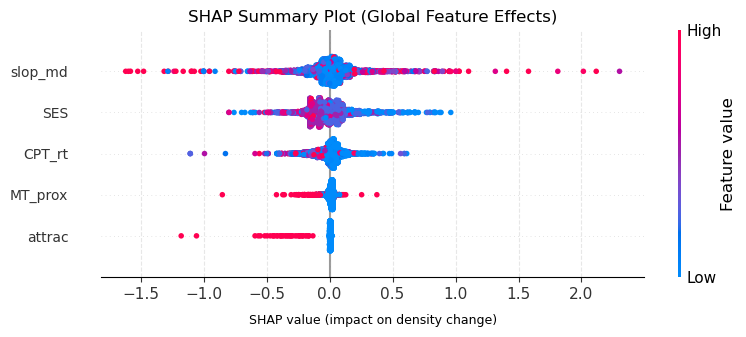

In [19]:
# SHAP GLOBAL 
plt.figure(figsize=(6, 5))

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(
    shap_values,
    X_test,
    show=False)

plt.title("SHAP Summary Plot (Global Feature Effects)", fontsize=12)
plt.xlabel("SHAP value (impact on density change)", fontsize=9)
plt.ylabel("")

# clean style
ax = plt.gca()
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.set_label_coords(0.5, -0.15)

# grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# predictions on test set
y_pred = rf.predict(X_test)

# convertir a serie para conservar índices
pred_series = pd.Series(y_pred, index=X_test.index)

# highest, lowest, and median-like cases
high_idx = pred_series.idxmax()
low_idx = pred_series.idxmin()
mid_idx = (pred_series - pred_series.median()).abs().idxmin()

print("High:", high_idx)
print("Low:", low_idx)
print("Middle:", mid_idx)

high_pos = X_test.index.get_loc(high_idx)
low_pos = X_test.index.get_loc(low_idx)
mid_pos = X_test.index.get_loc(mid_idx)

print("High index:", high_pos)
print("Low index:", low_pos)
print("Middle index:", mid_pos)

High: 10067
Low: 4104
Middle: 4161
High index: 1712
Low index: 2789
Middle index: 2986


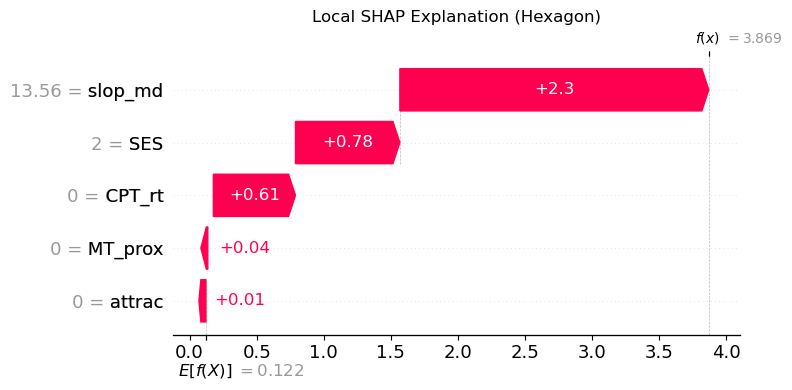

In [21]:
i = 1712  

plt.figure(figsize=(5, 4))
shap.plots.waterfall(shap_values[i], show=False)

ax = plt.gca()

# titles
ax.set_title("Local SHAP Explanation (Hexagon)", fontsize=12)

# labels
ax.tick_params(axis='both', labelsize=10)

# clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

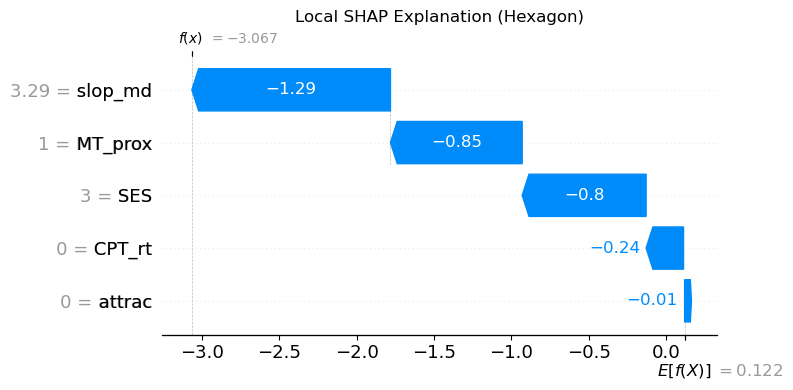

In [22]:
i = 2789 

plt.figure(figsize=(5, 4))
shap.plots.waterfall(shap_values[i], show=False)

ax = plt.gca()

# titles
ax.set_title("Local SHAP Explanation (Hexagon)", fontsize=12)

# labels
ax.tick_params(axis='both', labelsize=10)

# clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

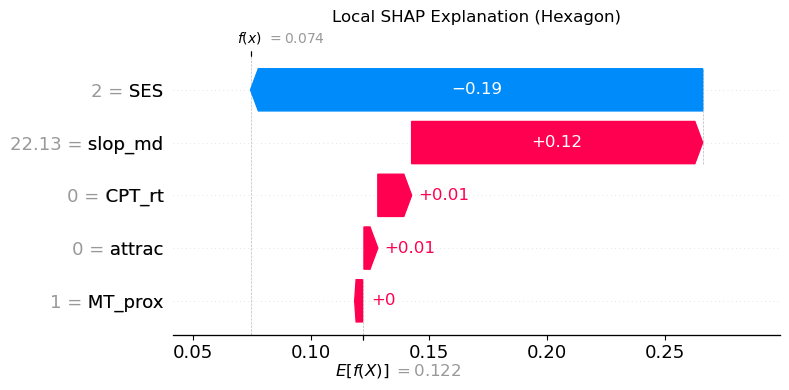

In [23]:
i = 2986 

plt.figure(figsize=(5, 4))
shap.plots.waterfall(shap_values[i], show=False)

ax = plt.gca()

# titles
ax.set_title("Local SHAP Explanation (Hexagon)", fontsize=12)

# labels
ax.tick_params(axis='both', labelsize=10)

# clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

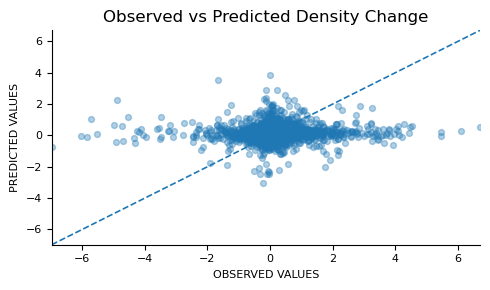

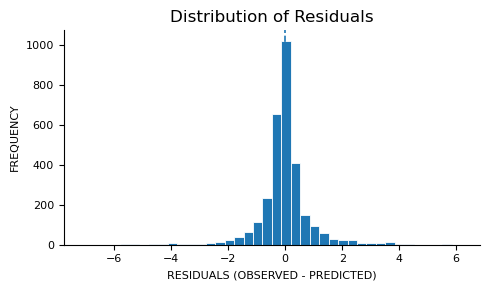

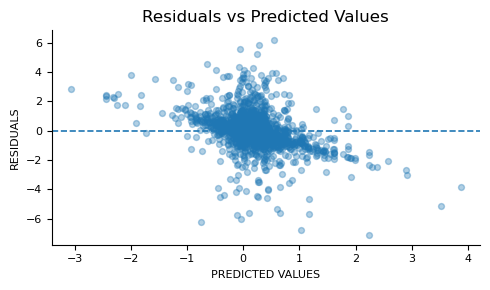

In [28]:
# --------------------------------------------------
# OBSERVED VS PREDICTED + RESIDUALS
# --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# y_test and y_pred already created before this block
residuals = y_test - y_pred

# -----------------------------
# 1. Observed vs Predicted
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(y_test, y_pred, alpha=0.35, s=18)

# 45-degree reference line
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
ax.plot(lims, lims, linestyle="--", linewidth=1.2)
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title("Observed vs Predicted Density Change", fontsize=12)
ax.set_xlabel("OBSERVED VALUES", fontsize=8)
ax.set_ylabel("PREDICTED VALUES", fontsize=8)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


# -----------------------------
# 2. Residual histogram
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.hist(residuals, bins=40, edgecolor="white", linewidth=0.6)
ax.axvline(x=0, linestyle="--", linewidth=1.2)

ax.set_title("Distribution of Residuals", fontsize=12)
ax.set_xlabel("RESIDUALS (OBSERVED - PREDICTED)", fontsize=8)
ax.set_ylabel("FREQUENCY", fontsize=8)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


# -----------------------------
# 3. Residual plot
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(y_pred, residuals, alpha=0.35, s=18)
ax.axhline(y=0, linestyle="--", linewidth=1.2)

ax.set_title("Residuals vs Predicted Values", fontsize=12)
ax.set_xlabel("PREDICTED VALUES", fontsize=8)
ax.set_ylabel("RESIDUALS", fontsize=8)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

The Random Forest model shows limited predictive performance, with a negative R² (-0.19) and an RMSE of approximately 0.96. This indicates that the model is unable to accurately predict variation in population density change across hexagons.

The observed vs predicted plot (Figure X) shows that predictions are highly concentrated around the mean, with limited alignment along the 45-degree reference line. This indicates that the model struggles to reproduce extreme values of density change, instead regressing predictions towards the centre.

This pattern is further supported by the residual plots, which show substantial dispersion around zero and increasing error for more extreme predicted values. The lack of a clear random distribution suggests that the model does not fully capture the underlying structure of the data.

Feature importance results from the Random Forest suggest that median slope (slop_md) is the dominant variable, accounting for a substantial proportion of the model’s explanatory power. This is followed by CPT_rt (number of conventional transport routes) and SES, while MT_prox and attrac show minimal contribution.

However, permutation feature importance provides a different perspective. In this case, SES emerges as the most relevant variable, while slope and other predictors show only marginal contributions. Notably, some variables such as CPT_rt display negative importance, suggesting that their inclusion may not improve model performance.

SHAP analysis reinforces these findings. At a global level, slope and SES show the largest variation in SHAP values, indicating that these variables have the strongest influence on predictions. At the local level, individual explanations reveal that the contribution of predictors varies substantially across observations, with slope consistently exerting strong positive or negative effects depending on context.

These results suggest that the selected variables are insufficient to capture the mechanisms driving density change, rather than simply indicating weak relationships.

**Limitations**

While Random Forest models are effective at capturing non-linear relationships, they do not provide causal interpretations. As such, the results should be understood as associations rather than direct effects.

In addition, model performance is dependent on the quality and completeness of the input data. The absence of key variables, such as land-use regulation, housing market dynamics, or informal development processes, may limit the ability of the model to accurately capture the drivers of density change.

This is particularly relevant given the exploratory nature of the study and the complexity of urban systems in contexts such as Lima.

## Conclusion

[[ go back to the top ]](#Table-of-contents)

The poor predictive performance of the model suggests that the selected variables do not adequately capture the processes driving population density change in Lima. The negative R² indicates that the model performs worse than a simple mean-based prediction, highlighting the limited explanatory power of accessibility, topographic, and basic socio-economic variables in this context. This is also evident in the model diagnostics, where predictions are concentrated around average values and fail to capture extremes, reinforcing the limited explanatory power of the selected variables.

This finding challenges assumptions derived from Transit-Oriented Development (TOD) theory, which often emphasises accessibility as a key driver of urban densification. In the case of Lima, accessibility variables such as proximity to mass transit and the number of transport routes show minimal and inconsistent influence across all interpretation methods.

Instead, the relative importance of slope and socio-economic status suggests that physical constraints and existing socio-spatial inequalities may play a more significant role in shaping density patterns. However, even these variables do not provide strong predictive power, indicating that density change is likely influenced by more complex and unobserved dynamics.

A substantial body of literature on Latin American urbanisation supports this interpretation. Processes such as informal urban development (De Soto, 1989; Roy, 2005), land market dynamics (Harvey, 1985; Smith, 1979), and regulatory fragmentation (Vega Centeno, 2017) have been shown to play a critical role in shaping urban growth. These processes are often spatially heterogeneous and poorly captured in formal datasets.

In addition, urban growth is influenced by path dependency and pre-existing urban structure (Jacobs, 1961), which may explain why density change does not respond directly to new infrastructure alone. In Lima, where informal development and incremental urbanisation are prevalent, the relationship between transport investment and densification is likely indirect and mediated by institutional and socio-economic factors.

Overall, the results highlight a key limitation of data-driven approaches in contexts with incomplete or uneven data availability. The findings suggest that important drivers of density change remain unobserved, and that improving data collection—particularly regarding land use regulation, informal settlements, and land market dynamics—would be essential for more robust modelling.

## References

[[ go back to the top ]](#Table-of-contents)

Autoridad de Transporte Urbano para Lima y Callao (ATU) (n/d) Información geográfica de transporte metropolitano (WWW), Lima: ATU.
    
Censo Nacional de Población y Vivienda (2007) Censos Nacionales 2007, Lima: Instituto Nacional de Estadística e Informática (INEI).
    
Censo Nacional de Población y Vivienda (2017) Censos Nacionales 2017, Lima: Instituto Nacional de Estadística e Informática (INEI).

Cervero, R. and Kockelman, K. (1997) ‘Travel demand and the 3Ds: density, diversity, and design’, Journal of the American Planning Association, 63, 2, 199–219. https://doi.org/10.1016/S1361-9209(97)00009-6

Japan Aerospace Exploration Agency (JAXA) (n/d) ALOS PALSAR digital elevation model (12.5 × 12.5 m resolution) (WWW), Tokyo: JAXA (accessed 15 April 2026).

Vega Centeno, P. (ed.) (2014) Lima, diversidad y fragmentación de una metrópoli emergente, Quito: OLACCHI.